In [36]:
import pandas as pd

import matplotlib.pyplot as plt

df_b1 = pd.read_csv("../data/processed/bioshock_1_themed.csv")
df_b2 = pd.read_csv("../data/processed/bioshock_2_themed.csv")
df_inf = pd.read_csv("../data/processed/bioshock_infinite_themed.csv")

print(len(df_b1), len(df_b2), len(df_inf))

print(df_b1["technical"].dtype)

26155 12008 47232
bool


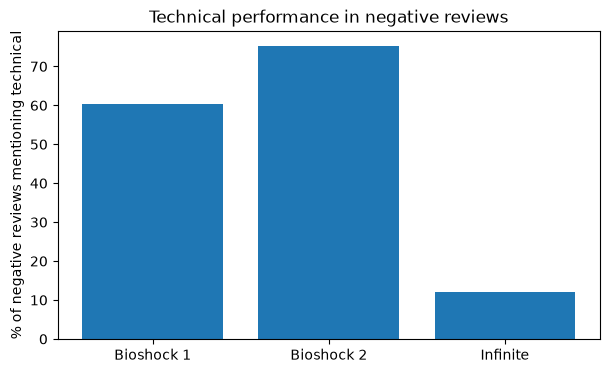

[np.float64(60.5), np.float64(75.3), np.float64(12.0)]


In [37]:
games = ["Bioshock 1", "Bioshock 2", "Infinite"]
neg_pct = [
    df_b1[df_b1["voted_up"] == False]["technical"].mean() *100,
    df_b2[df_b2["voted_up"] == False]["technical"].mean() *100,
    df_inf[df_inf["voted_up"] == False]["technical"].mean() *100,
]

fig, ax = plt.subplots(figsize= (7, 4))
ax.bar(games, neg_pct)
ax.set_ylabel("% of negative reviews mentioning technical")
ax.set_title("Technical performance in negative reviews")
plt.show()

print([round(p, 1) for p in neg_pct])

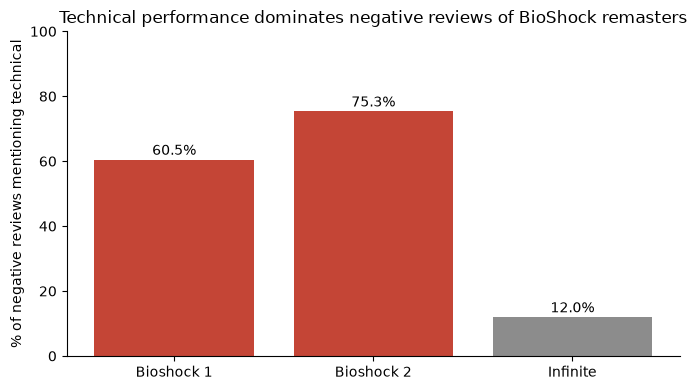

In [38]:
fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(games, neg_pct, color=["#c44536", "#c44536", "#8c8c8c"])

for bar, pct in zip(bars, neg_pct):
    ax.text(bar.get_x() + bar.get_width() / 2, pct + 1.5, f"{pct:.1f}%", ha="center")

ax.set_ylabel("% of negative reviews mentioning technical")
ax.set_title("Technical performance dominates negative reviews of remasters")
ax.set_ylim(0, 100)
ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.show()

In [39]:
plt.savefig("../outputs/figures/f2_technical_negatives.png", dpi=200)

<Figure size 640x480 with 0 Axes>

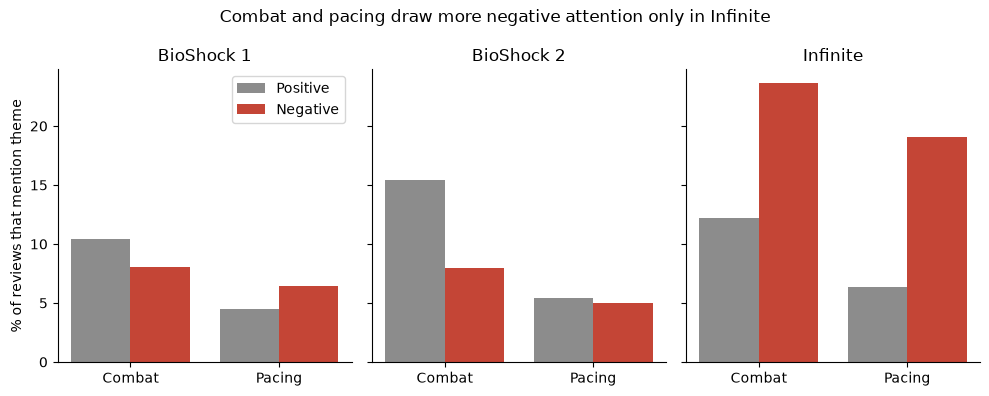

In [44]:
frames = [df_b1, df_b2, df_inf]
titles = ["BioShock 1", "BioShock 2", "Infinite"]

fig, axes = plt.subplots(1, 3, figsize=(10, 4), sharey=True)

for ax, df_g, title in zip(axes, frames, titles):
    pos = df_g[df_g["voted_up"] == True]
    neg = df_g[df_g["voted_up"] == False]

    pos_vals = [pos["combat"].mean() * 100, pos["pacing"].mean() * 100]
    neg_vals = [neg["combat"].mean() * 100, neg["pacing"].mean() * 100]

    ax.bar([0 - 0.2, 1 - 0.2], pos_vals, 0.4, label="Positive", color="#8c8c8c")
    ax.bar([0 + 0.2, 1 + 0.2], neg_vals, 0.4, label="Negative", color="#c44536")

    ax.set_xticks([0, 1])
    ax.set_xticklabels(["Combat", "Pacing"])
    ax.set_title(title)
    ax.spines[["top", "right"]].set_visible(False)

axes[0].set_ylabel("% of reviews that mention theme")
axes[0].legend()

fig.suptitle("Combat and pacing draw more negative attention only in Infinite")
plt.tight_layout()
plt.show()

In [41]:
plt.savefig("../outputs/figures/f4_gamefeel_small_multiples.png", dpi=200)

<Figure size 640x480 with 0 Axes>

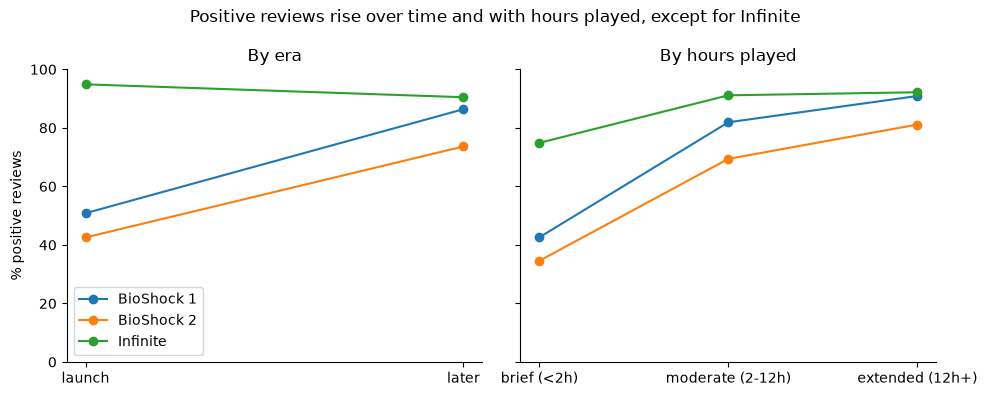

In [42]:
era_order = ["launch", "later"]
seg_order = ["brief (<2h)", "moderate (2-12h)", "extended (12h+)"]

fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharey=True)

for df_g, label in [(df_b1, "BioShock 1"), (df_b2, "BioShock 2"), (df_inf, "Infinite")]:
    era_pcts = []
    for e in era_order:
        sub = df_g[df_g["era"] == e]
        era_pcts.append(sub["voted_up"].mean() * 100)
    axes[0].plot(era_order, era_pcts, marker="o", label=label)

    seg_pcts = []
    for s in seg_order:
        sub = df_g[df_g["segment"] == s]
        seg_pcts.append(sub["voted_up"].mean() * 100)
    axes[1].plot(seg_order, seg_pcts, marker="o", label=label)

axes[0].set_title("By era")
axes[1].set_title("By hours played")
axes[0].set_ylabel("% positive reviews")
axes[0].set_ylim(0, 100)
axes[0].legend()

for ax in axes:
    ax.spines[["top", "right"]].set_visible(False)

fig.suptitle("Positive reviews rise over time and with hours played, except for Infinite")
plt.tight_layout()
plt.show()

In [43]:
plt.savefig("../outputs/figures/f3_era_and_playtime.png", dpi=200)

<Figure size 640x480 with 0 Axes>